In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron  # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential  # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense       # Dense neural network layer
from tensorflow.keras.layers import Conv2D      # Convolutional layer
from tensorflow.keras.layers import Flatten     # Flatten layer

from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout


In [28]:
from tensorflow.keras.utils import to_categorical  # converts numeric class labels into one-hot encoded format for training classification models
from tensorflow.keras.datasets import mnist
df, df_test = mnist.load_data()

In [29]:
np.unique(df[1],return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949],
       dtype=int64))

In [30]:
df[0].shape

(60000, 28, 28)

In [5]:
x_train_scaled = df[0].astype(np.float32)/255.0
x_test_scaled = df_test[0].astype(np.float32)/255.0
y_train = df[1]
y_test = df_test[1]

In [6]:
x_test_scaled.shape

(10000, 28, 28)

In [7]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [8]:
Perceptron = Sequential([
    Flatten(input_shape = (28,28)),
    Dense(10,activation='softmax')
])

In [9]:
Perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [10]:
history = Perceptron.fit(x_train_scaled,y_train_cat,epochs=5,
                        batch_size=32,validation_data=(x_test_scaled, y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8167 - loss: 0.7737 - val_accuracy: 0.8817 - val_loss: 0.4801
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8800 - loss: 0.4557 - val_accuracy: 0.8945 - val_loss: 0.3999
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8913 - loss: 0.4025 - val_accuracy: 0.9011 - val_loss: 0.3672
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8968 - loss: 0.3763 - val_accuracy: 0.9063 - val_loss: 0.3477
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9009 - loss: 0.3597 - val_accuracy: 0.9080 - val_loss: 0.3355


In [11]:
acc_percep = Perceptron.evaluate(x_test_scaled,y_test_cat,verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9080 - loss: 0.3355 


In [12]:
acc_percep

[0.33554255962371826, 0.9079999923706055]

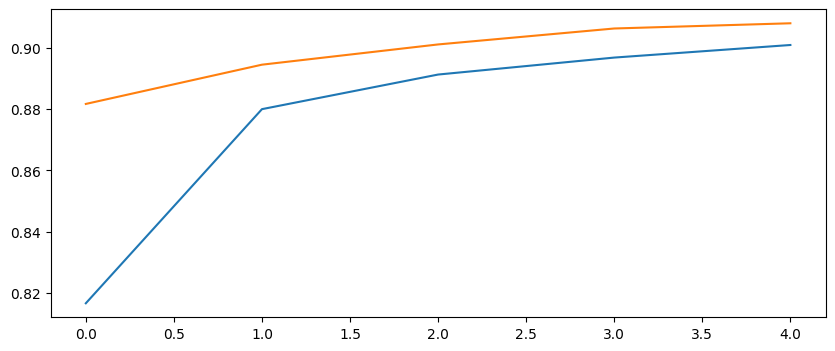

In [13]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'],label='training accuracy')
plt.plot(history.history['val_accuracy'],label='training accuracy')

In [14]:
#ANN
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [15]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [16]:
history_ann = ann.fit(x_train_scaled,y_train_cat,epochs=5,batch_size=32,
                     validation_data=(x_test_scaled,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9306 - loss: 0.2373 - val_accuracy: 0.9645 - val_loss: 0.1198
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9696 - loss: 0.1000 - val_accuracy: 0.9657 - val_loss: 0.1097
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9772 - loss: 0.0717 - val_accuracy: 0.9755 - val_loss: 0.0759
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9832 - loss: 0.0529 - val_accuracy: 0.9746 - val_loss: 0.0812
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9862 - loss: 0.0423 - val_accuracy: 0.9768 - val_loss: 0.0822


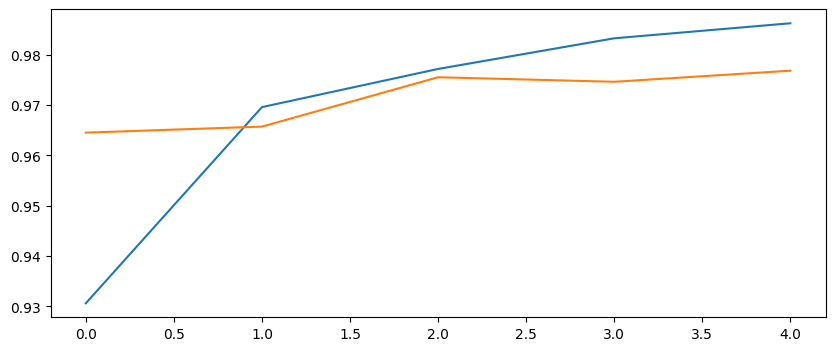

In [17]:
plt.figure(figsize=(10,4))
plt.plot(history_ann.history['accuracy'],label='training accuracy')
plt.plot(history_ann.history['val_accuracy'],label='training accuracy')

In [23]:
cnn = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [25]:
x_train_cnn = df[0].reshape(-1, 28, 28, 1)
x_test_cnn = df_test[0].reshape(-1, 28, 28, 1)

In [26]:
cnn.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

In [27]:
history_cnn = cnn.fit(x_train_cnn,y_train_cat,epochs=5,batch_size=32,
                     validation_data=(x_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8634 - loss: 0.5103 - val_accuracy: 0.9787 - val_loss: 0.0718
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9591 - loss: 0.1425 - val_accuracy: 0.9833 - val_loss: 0.0617
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9685 - loss: 0.1099 - val_accuracy: 0.9870 - val_loss: 0.0456
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9738 - loss: 0.0918 - val_accuracy: 0.9872 - val_loss: 0.0441
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9770 - loss: 0.0789 - val_accuracy: 0.9882 - val_loss: 0.0393
